# HW12

## 1. Импорты, seed и среда

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import json
import os

# Фиксируем seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

D:\Programs\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Using device: cpu


## 2. Данные и первичный анализ

Размер датасета: 4320
Диапазон дат: 2025-01-01 00:00:00 – 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


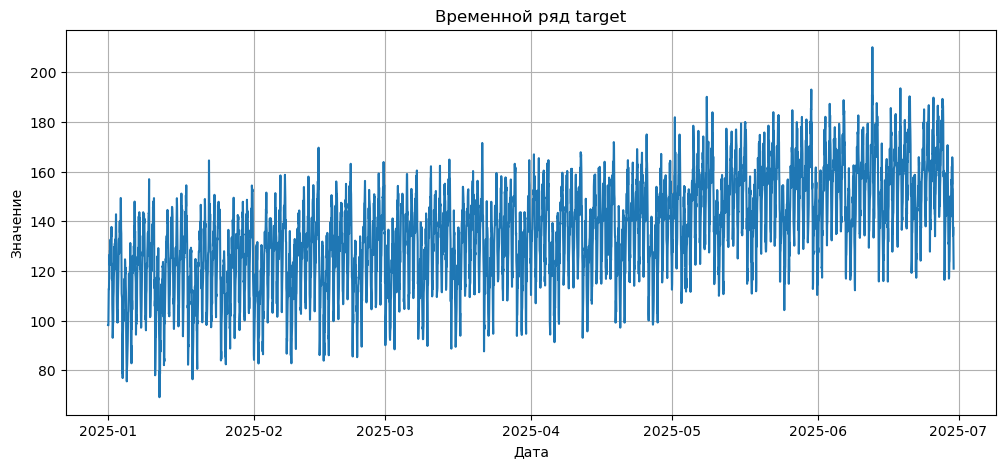

In [2]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Размер датасета: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} – {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['target'])
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True)
plt.show()

# Комментарий: виден суточный цикл (пик днём, минимум ночью) и общий восходящий тренд. Присутствуют выбросы (например, 210 в июне).
# Ряд нестационарен из-за тренда и сезонности.

## 3. Корректный temporal split

Train: 2025-01-01 00:00:00 – 2025-05-06 23:00:00 (3024 rows)
Val:   2025-05-07 00:00:00 – 2025-06-02 23:00:00 (648 rows)
Test:  2025-06-03 00:00:00 – 2025-06-29 23:00:00 (648 rows)


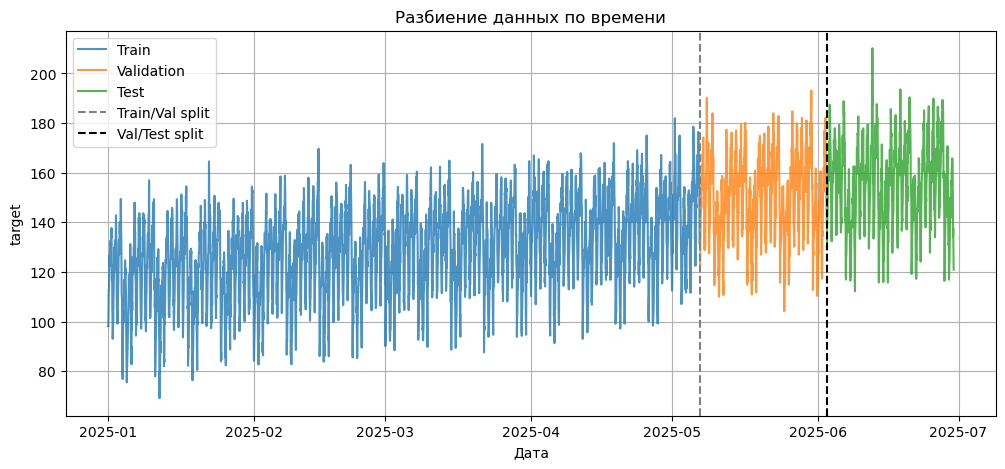

In [3]:
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print(f"Train: {train['date'].min()} – {train['date'].max()} ({len(train)} rows)")
print(f"Val:   {val['date'].min()} – {val['date'].max()} ({len(val)} rows)")
print(f"Test:  {test['date'].min()} – {test['date'].max()} ({len(test)} rows)")

# Визуализация split
plt.figure(figsize=(12,5))
plt.plot(train['date'], train['target'], label='Train', alpha=0.8)
plt.plot(val['date'], val['target'], label='Validation', alpha=0.8)
plt.plot(test['date'], test['target'], label='Test', alpha=0.8)
plt.axvline(x=train['date'].iloc[-1], color='gray', linestyle='--', label='Train/Val split')
plt.axvline(x=val['date'].iloc[-1], color='black', linestyle='--', label='Val/Test split')
plt.title('Разбиение данных по времени')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Пояснение: random split перемешал бы порядок наблюдений, нарушив временную структуру,
# и модель бы «увидела» будущие данные при обучении, что дало бы нереалистично хорошие результаты.
# При temporal split обучаем на прошлых данных, валидируем на промежуточных, тестируем на самых свежих.

**Почему random split недопустим для временных рядов?**

Временной ряд имеет естественный хронологический порядок. Случайное перемешивание строк перед разбиением привело бы к тому, что модель обучалась бы на данных из будущего и проверялась на данных из прошлого. Это дало бы нереалистично завышенную оценку качества, которая не сохранится при прогнозировании на реальных новых данных (которые всегда идут после обучающего периода). Поэтому мы используем **temporal split**: обучаем на первых 70% данных, валидируем на следующих 15%, тестируем на последних 15%, строго соблюдая порядок времени.

## 4. Признаки для baseline-моделей

In [4]:
def add_features(df, lags=[1,7,14], roll_wins=[7]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['target'].shift(lag)
    for win in roll_wins:
        df[f'rolling_mean_{win}'] = df['target'].rolling(win).mean()
        df[f'rolling_std_{win}'] = df['target'].rolling(win).std()
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    return df

# Для train: добавляем признаки на основе только train, но shift/rolling могут заглядывать в будущее?
# shift и rolling используют только прошлые значения (при правильной сортировке), поэтому OK.
train_feat = add_features(train)
val_feat = add_features(val)
test_feat = add_features(test)

# Удаляем строки с NaN, которые возникли из-за lag/rolling
train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

feature_cols = [c for c in train_feat.columns if c not in ['date','target']]
X_train = train_feat[feature_cols]
y_train = train_feat['target']
X_val = val_feat[feature_cols]
y_val = val_feat['target']
X_test = test_feat[feature_cols]
y_test = test_feat['target']

# Масштабирование (fit на train, transform на val/test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Признаки:", feature_cols)
print(f"Размеры: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")

Признаки: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'month']
Размеры: train (3010, 8), val (634, 8), test (634, 8)


## 5. Эксперименты

### 5.1. B1 – Naive last

Прогноз на момент t – значение в момент t-1.

In [5]:
# B1 – Naive last
full_series = np.concatenate([train['target'].values, val['target'].values, test['target'].values])
val_start = len(train)          # индекс начала валидации
test_start = len(train) + len(val)  # индекс начала теста

# Прогнозы для валидации: для i от val_start до test_start-1, прогноз = значение в i-1
y_val_naive = full_series[val_start-1 : test_start-1]   # длина = len(val)
# Прогнозы для теста: для i от test_start до конца, прогноз = значение в i-1
y_test_naive = full_series[test_start-1 : -1]           # длина = len(test)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_val_b1, rmse_val_b1, mape_val_b1 = compute_metrics(val['target'].values, y_val_naive)
mae_test_b1, rmse_test_b1, mape_test_b1 = compute_metrics(test['target'].values, y_test_naive)

print(f"B1 val: MAE={mae_val_b1:.2f}, RMSE={rmse_val_b1:.2f}, MAPE={mape_val_b1:.2f}%")
print(f"B1 test: MAE={mae_test_b1:.2f}, RMSE={rmse_test_b1:.2f}, MAPE={mape_test_b1:.2f}%")

B1 val: MAE=6.44, RMSE=8.20, MAPE=4.40%
B1 test: MAE=6.34, RMSE=8.06, MAPE=4.15%


### 5.2. B2 – Moving average (окно 7)

In [6]:
# B2 – Moving average (окно 7)
window = 7
y_val_ma = []
for i in range(val_start, test_start):
    y_val_ma.append(np.mean(full_series[i-window:i]))
y_test_ma = []
for i in range(test_start, len(full_series)):
    y_test_ma.append(np.mean(full_series[i-window:i]))

y_val_ma = np.array(y_val_ma)
y_test_ma = np.array(y_test_ma)

mae_val_b2, rmse_val_b2, mape_val_b2 = compute_metrics(val['target'].values, y_val_ma)
mae_test_b2, rmse_test_b2, mape_test_b2 = compute_metrics(test['target'].values, y_test_ma)

print(f"B2 val: MAE={mae_val_b2:.2f}, RMSE={rmse_val_b2:.2f}, MAPE={mape_val_b2:.2f}%")
print(f"B2 test: MAE={mae_test_b2:.2f}, RMSE={rmse_test_b2:.2f}, MAPE={mape_test_b2:.2f}%")

B2 val: MAE=12.70, RMSE=15.22, MAPE=8.82%
B2 test: MAE=12.74, RMSE=15.24, MAPE=8.55%


### 5.3. B3 – Ridge на признаках

In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_val_ridge = ridge.predict(X_val_scaled)
y_test_ridge = ridge.predict(X_test_scaled)

mae_val_b3, rmse_val_b3, mape_val_b3 = compute_metrics(y_val, y_val_ridge)
mae_test_b3, rmse_test_b3, mape_test_b3 = compute_metrics(y_test, y_test_ridge)

print(f"B3 val: MAE={mae_val_b3:.2f}, RMSE={rmse_val_b3:.2f}, MAPE={mape_val_b3:.2f}%")
print(f"B3 test: MAE={mae_test_b3:.2f}, RMSE={rmse_test_b3:.2f}, MAPE={mape_test_b3:.2f}%")

B3 val: MAE=5.46, RMSE=6.82, MAPE=3.67%
B3 test: MAE=5.32, RMSE=6.82, MAPE=3.44%


### 5.4. R1 – GRU

#### 5.4.1. Подготовка последовательностей

In [8]:
WINDOW_SIZE = 24  # 24 часа

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size):
        self.series = series
        self.window = window_size
    def __len__(self):
        return len(self.series) - self.window
    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window]
        y = self.series[idx+self.window]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

# Масштабирование target
target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train['target'].values.reshape(-1,1)).ravel()
val_target_scaled = target_scaler.transform(val['target'].values.reshape(-1,1)).ravel()
test_target_scaled = target_scaler.transform(test['target'].values.reshape(-1,1)).ravel()

# Создаём датасеты
train_dataset = TimeSeriesDataset(train_target_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(val_target_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(test_target_scaled, WINDOW_SIZE)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#### 5.4.2. Модель GRU

In [9]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.gru(x)  # out: (batch, seq_len, hidden)
        out = out[:, -1, :]   # последний выход
        return self.fc(out).squeeze()

model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

#### 5.4.3. Обучение

Epoch 10: train loss = 0.1433, val loss = 0.1709
Epoch 20: train loss = 0.1014, val loss = 0.1428
Epoch 30: train loss = 0.0980, val loss = 0.1410
Epoch 40: train loss = 0.0954, val loss = 0.1396
Epoch 50: train loss = 0.0937, val loss = 0.1386


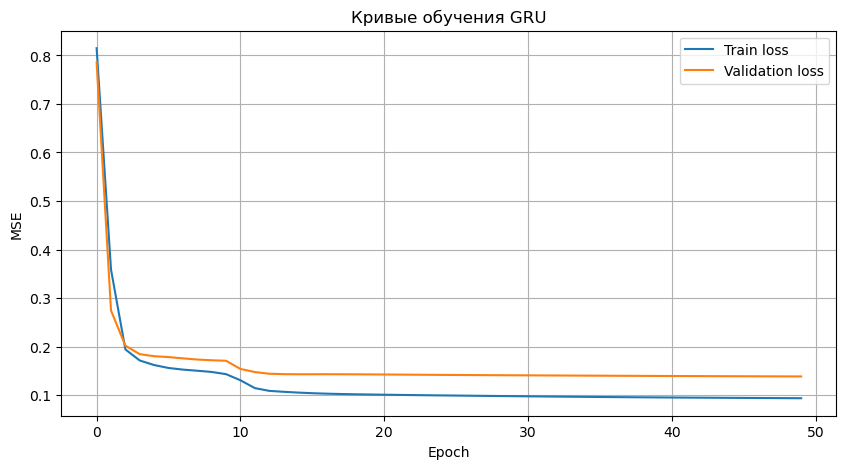

In [10]:
epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: train loss = {train_loss:.4f}, val loss = {val_loss:.4f}")

# Загружаем лучшую модель
model.load_state_dict(best_model_state)

# Кривые обучения
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Кривые обучения GRU')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Сохраняем модель и конфиг
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
config = {
    'window_size': WINDOW_SIZE,
    'hidden_size': 64,
    'num_layers': 1,
    'batch_size': batch_size,
    'lr': 0.001,
    'seed': SEED,
    'scaler': 'StandardScaler',
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

#### 5.4.4. Оценка на validation и test

In [11]:
def get_predictions(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            pred = model(x).cpu().numpy()
            preds.append(pred)
    return np.concatenate(preds)

y_pred_val_scaled = get_predictions(model, val_loader)
y_pred_test_scaled = get_predictions(model, test_loader)

# Обратное масштабирование
y_val_true = val['target'].values[WINDOW_SIZE:]
y_test_true = test['target'].values[WINDOW_SIZE:]
y_val_pred = target_scaler.inverse_transform(y_pred_val_scaled.reshape(-1,1)).ravel()
y_test_pred = target_scaler.inverse_transform(y_pred_test_scaled.reshape(-1,1)).ravel()

mae_val_r1, rmse_val_r1, mape_val_r1 = compute_metrics(y_val_true, y_val_pred)
mae_test_r1, rmse_test_r1, mape_test_r1 = compute_metrics(y_test_true, y_test_pred)

print(f"R1 val: MAE={mae_val_r1:.2f}, RMSE={rmse_val_r1:.2f}, MAPE={mape_val_r1:.2f}%")
print(f"R1 test: MAE={mae_test_r1:.2f}, RMSE={rmse_test_r1:.2f}, MAPE={mape_test_r1:.2f}%")

R1 val: MAE=5.31, RMSE=6.88, MAPE=3.60%
R1 test: MAE=6.27, RMSE=7.86, MAPE=4.08%


## 6. Сравнение и финальный выбор

Лучшая модель выбирается по минимальной валидационной MAE.

Лучшая модель по val MAE: R1


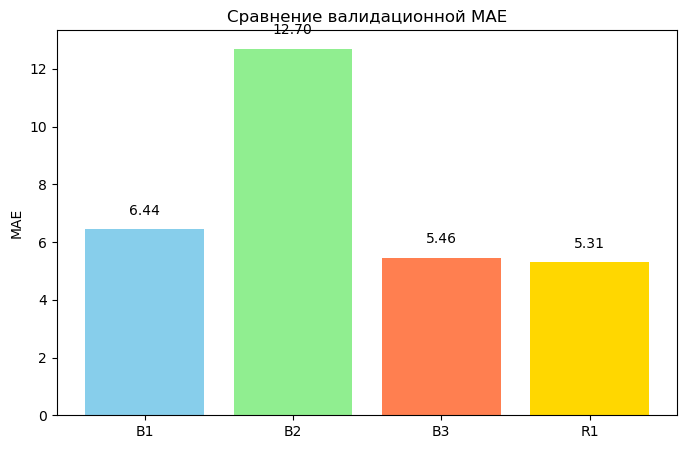

In [12]:
results = {
    'B1': (mae_val_b1, rmse_val_b1, mape_val_b1, mae_test_b1, rmse_test_b1, mape_test_b1),
    'B2': (mae_val_b2, rmse_val_b2, mape_val_b2, mae_test_b2, rmse_test_b2, mape_test_b2),
    'B3': (mae_val_b3, rmse_val_b3, mape_val_b3, mae_test_b3, rmse_test_b3, mape_test_b3),
    'R1': (mae_val_r1, rmse_val_r1, mape_val_r1, mae_test_r1, rmse_test_r1, mape_test_r1)
}

best_model = min(results, key=lambda x: results[x][0])
print(f"Лучшая модель по val MAE: {best_model}")

# Построение графика сравнения
models = list(results.keys())
val_mae = [results[m][0] for m in models]

plt.figure(figsize=(8,5))
bars = plt.bar(models, val_mae, color=['skyblue','lightgreen','coral','gold'])
plt.title('Сравнение валидационной MAE')
plt.ylabel('MAE')
for bar, val in zip(bars, val_mae):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}', ha='center')
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Финальная оценка на test для лучшей модели

(Мы уже вычислили test-метрики для всех моделей, но для отчёта выберем лучшую)

In [13]:
print(f"Финальные метрики для {best_model}:")
print(f"  Test MAE:  {results[best_model][3]:.2f}")
print(f"  Test RMSE: {results[best_model][4]:.2f}")
print(f"  Test MAPE: {results[best_model][5]:.2f}%")

Финальные метрики для R1:
  Test MAE:  6.27
  Test RMSE: 7.86
  Test MAPE: 4.08%


## 8. Визуализация прогноза лучшей модели на test

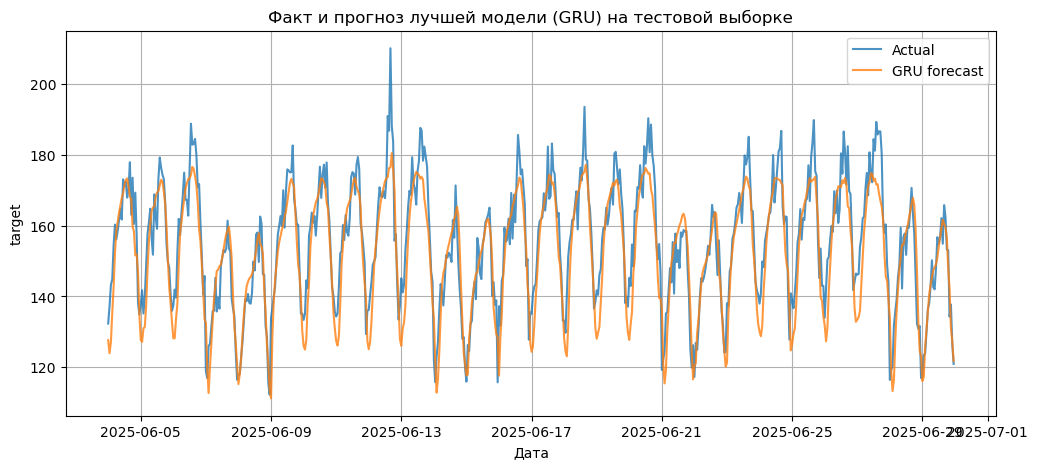

In [14]:
plt.figure(figsize=(12,5))
plt.plot(test['date'].values[WINDOW_SIZE:], y_test_true, label='Actual', alpha=0.8)
plt.plot(test['date'].values[WINDOW_SIZE:], y_test_pred, label='GRU forecast', alpha=0.8)
plt.title('Факт и прогноз лучшей модели (GRU) на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Сохранение результатов в runs.csv

In [15]:
runs = []
best_model_id = 'R1'   # лучшая модель по val MAE

for exp_id in ['B1','B2','B3','R1']:
    mae_val, rmse_val, mape_val, mae_test, rmse_test, mape_test = results[exp_id]
    # Оставляем test-метрики только для лучшей модели
    if exp_id == best_model_id:
        test_mae_val = mae_test
        test_rmse_val = rmse_test
        test_mape_val = mape_test
    else:
        test_mae_val = None
        test_rmse_val = None
        test_mape_val = None
        
    runs.append({
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train:{train_end} val:{val_end-train_end} test:{n-val_end}',
        'window_size': WINDOW_SIZE if exp_id == 'R1' else None,
        'horizon': 1,
        'model_summary': 'NaiveLast' if exp_id=='B1' else 'MovingAverage7' if exp_id=='B2' else 'Ridge' if exp_id=='B3' else 'GRU',
        'features_summary': 'None' if exp_id in ['B1','B2'] else ','.join(feature_cols) if exp_id=='B3' else 'target only',
        'scaler': 'None' if exp_id in ['B1','B2'] else 'StandardScaler',
        'optimizer': 'Adam' if exp_id=='R1' else None,
        'lr': 0.001 if exp_id=='R1' else None,
        'epochs_trained': epochs if exp_id=='R1' else None,
        'best_val_mae': mae_val,
        'best_val_rmse': rmse_val,
        'best_val_mape': mape_val,
        'test_mae': test_mae_val,
        'test_rmse': test_rmse_val,
        'test_mape': test_mape_val,
        'notes': ''
    })

df_runs = pd.DataFrame(runs)
df_runs.to_csv('artifacts/runs.csv', index=False)
print("runs.csv сохранён")
print(df_runs[['experiment_id','best_val_mae','test_mae']])

runs.csv сохранён
  experiment_id  best_val_mae  test_mae
0            B1      6.444815       NaN
1            B2     12.702013       NaN
2            B3      5.459272       NaN
3            R1      5.313470  6.266826
